### Initial Database and Checks


In [ ]:
import os
import tensorflow as tf

# NOTE: may have to change batch size and epochs depending on GPU VRAM. but epochs should be kept to 100 if possible for train accuracy.
CLEAR_BEFORE_TRAIN = True
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 1e-3
TRAIN_END = 15000
HOLDOUT_END = TRAIN_END + 2000
STEPS = TRAIN_END//2 // BATCH_SIZE + 1
BETA = 6.0

# Define your checkpoint directory
checkpoint_dir = './checkpoints'
models_dir = './models'
prep_model_path = os.path.join(models_dir, 'prep_model.keras')
hide_model_path = os.path.join(models_dir, 'hide_model.keras')
reveal_model_path = os.path.join(models_dir, 'reveal_model.keras')

I0000 00:00:1774313572.937251   43961 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774313572.976460   43961 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774313574.472763   43961 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split
# 1. Clear Ghost Memory:
# Previous crashes leave "zombie" graphs in the GPU memory. This flushes them out.
tf.keras.backend.clear_session()
# 2. Enable Memory Growth:
# Prevents TensorFlow from blindly allocating 100% of the VRAM immediately.
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        for gpu in physical_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# 3. Enable Mixed Precision (The Silver Bullet):
# This forces the GPU to use float16 for calculations but keeps variables in float32.
# It literally cuts your VRAM requirement in half without hurting accuracy.
tf.keras.mixed_precision.set_global_policy('mixed_float16')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = "3"

# === GPU CHECK ===
print("=" * 60)
print("GPU/CUDA Configuration Check")
print("=" * 60)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Devices Available: {len(physical_devices)}")
if physical_devices:
    for i, gpu in enumerate(physical_devices):
        print(f"  GPU {i}: {gpu}")
else:
    print("  ⚠️  WARNING: No GPUs detected! Training will be SLOW.")

# Display nvidia-smi output
print("\n" + "=" * 60)
print("NVIDIA GPU Status (nvidia-smi)")
print("=" * 60)
try:
    import subprocess
    result = subprocess.run(
        ['nvidia-smi'], capture_output=True, text=True, timeout=5)
    print(result.stdout)
    if result.stderr:
        print("Errors:", result.stderr)
except Exception as e:
    print(f"Could not run nvidia-smi: {e}")
print("=" * 60 + "\n")


# Load Dataset
dataset = load_dataset("zh-plus/tiny-imagenet")
train_pool = dataset['train']['image'][:TRAIN_END]
holdout_pool = dataset['train']['image'][TRAIN_END:HOLDOUT_END]

train_cover, train_secret = train_test_split(
    train_pool, train_size=0.5, shuffle=True)
test_cover, test_secret = train_test_split(
    dataset['valid']['image'][:1000], train_size=0.5, shuffle=True)
holdout_cover, holdout_secret = train_test_split(
    holdout_pool,  # Taking the next 1000 images
    train_size=0.5,
    shuffle=True
)
del train_pool, holdout_pool, dataset  # Free memory


# === OPTIMIZATION: Pre-convert all PIL images to numpy arrays once ===
# This eliminates the ~5-10ms PIL conversion overhead on EVERY training step
print("Converting images to numpy arrays (one-time conversion)...")
train_cover_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in train_cover])
train_secret_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in train_secret])
test_cover_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in test_cover])
test_secret_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in test_secret])
holdout_cover_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in holdout_cover])
holdout_secret_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in holdout_secret])
print(f"✓ Image conversion complete! ({len(train_cover_np)} training pairs)")

# Build optimized tf.data pipelines
# Switched from from_generator() to from_tensor_slices() for 2-3x faster data loading
# Increased shuffle buffer from 1000 → 10000 for better shuffling
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_cover_np, train_secret_np)
).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_cover_np, test_secret_np)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

holdout_dataset = tf.data.Dataset.from_tensor_slices(
    (holdout_cover_np, holdout_secret_np)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

GPU/CUDA Configuration Check
TensorFlow version: 2.21.0
GPU Devices Available: 1
  GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

NVIDIA GPU Status (nvidia-smi)
Tue Mar 24 00:52:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 Ti     On  |   00000000:01:00.0  On |                  N/A |
| 35%   46C    P8             13W /  165W |  

Converting images to numpy arrays (one-time conversion)...
✓ Image conversion complete! (7500 training pairs)


I0000 00:00:1774313579.662415   43961 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5517 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


### NN Arch and Setup


In [3]:
from tensorflow.keras import layers, Model

initializer = tf.keras.initializers.GlorotNormal(seed=12541)


def build_keras_prep_network(input_shape=(64, 64, 3)):
    # 1. Define the Input Layer
    inputs = layers.Input(shape=input_shape, name="secret_image")

    # --- 3x3 Convolution Branch ---
    x3 = layers.Conv2D(50, (3, 3), padding='same', activation='relu',
                       kernel_initializer=initializer, bias_initializer='zeros', name='prep_conv3x3_1')(inputs)
    x3 = layers.Conv2D(50, (3, 3), padding='same', activation='relu',
                       kernel_initializer=initializer, bias_initializer='zeros', name='prep_conv3x3_2')(x3)
    x3 = layers.Conv2D(50, (3, 3), padding='same', activation='relu',
                       kernel_initializer=initializer, bias_initializer='zeros', name='prep_conv3x3_3')(x3)
    x3 = layers.Conv2D(50, (3, 3), padding='same', activation='relu',
                       kernel_initializer=initializer, bias_initializer='zeros', name='prep_conv3x3_4')(x3)

    # --- 4x4 Convolution Branch ---
    x4 = layers.Conv2D(50, (4, 4), padding='same', activation='relu',
                       kernel_initializer=initializer, bias_initializer='zeros', name='prep_conv4x4_1')(inputs)
    x4 = layers.Conv2D(50, (4, 4), padding='same', activation='relu',
                       kernel_initializer=initializer, bias_initializer='zeros', name='prep_conv4x4_2')(x4)
    x4 = layers.Conv2D(50, (4, 4), padding='same', activation='relu',
                       kernel_initializer=initializer, bias_initializer='zeros', name='prep_conv4x4_3')(x4)
    x4 = layers.Conv2D(50, (4, 4), padding='same', activation='relu',
                       kernel_initializer=initializer, bias_initializer='zeros', name='prep_conv4x4_4')(x4)

    # --- 5x5 Convolution Branch ---
    x5 = layers.Conv2D(50, (5, 5), padding='same', activation='relu',
                       kernel_initializer=initializer, bias_initializer='zeros', name='prep_conv5x5_1')(inputs)
    x5 = layers.Conv2D(50, (5, 5), padding='same', activation='relu',
                       kernel_initializer=initializer, bias_initializer='zeros', name='prep_conv5x5_2')(x5)
    x5 = layers.Conv2D(50, (5, 5), padding='same', activation='relu',
                       kernel_initializer=initializer, bias_initializer='zeros', name='prep_conv5x5_3')(x5)
    x5 = layers.Conv2D(50, (5, 5), padding='same', activation='relu',
                       kernel_initializer=initializer, bias_initializer='zeros', name='prep_conv5x5_4')(x5)

    # --- First Concatenation ---
    # Combines the outputs of the three branches (50 + 50 + 50 = 150 channels)
    concat_1 = layers.Concatenate(axis=3, name='prep_concat_1')([x3, x4, x5])

    # --- Final Convolution Layer for each branch ---
    x3_final = layers.Conv2D(50, (3, 3), padding='same', activation='relu',
                             kernel_initializer=initializer, bias_initializer='zeros', name='prep_conv3x3_5')(concat_1)
    x4_final = layers.Conv2D(50, (4, 4), padding='same', activation='relu',
                             kernel_initializer=initializer, bias_initializer='zeros', name='prep_conv4x4_5')(concat_1)
    x5_final = layers.Conv2D(50, (5, 5), padding='same', activation='relu',
                             kernel_initializer=initializer, bias_initializer='zeros', name='prep_conv5x5_5')(concat_1)

    # --- Final Concatenation ---
    # Final output shape will be (64, 64, 150)
    outputs = layers.Concatenate(axis=3, name='prep_output')([
        x3_final, x4_final, x5_final])

    # Create and return the Keras Model
    return Model(inputs=inputs, outputs=outputs, name="Keras_PrepNetwork")

In [4]:
def build_keras_hide_network(input_shape=(64, 64, 3), prep_channels=150):
    # Inputs
    cover_input = layers.Input(shape=input_shape, name="cover_input")
    prep_input = layers.Input(shape=(64, 64, prep_channels), name="prep_input")

    # Concatenate Cover and Prep (3 + 150 = 153 channels)
    concat_1 = layers.Concatenate(axis=3, name="hide_concat_1")([
        cover_input, prep_input])

    # --- 3x3, 4x4, 5x5 Branches ---
    def build_branch(inputs, kernel_size, name_prefix):
        x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                          kernel_initializer=initializer, bias_initializer='zeros', name=f'{name_prefix}_1')(inputs)
        x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                          kernel_initializer=initializer, bias_initializer='zeros', name=f'{name_prefix}_2')(x)
        x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                          kernel_initializer=initializer, bias_initializer='zeros', name=f'{name_prefix}_3')(x)
        x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                          kernel_initializer=initializer, bias_initializer='zeros', name=f'{name_prefix}_4')(x)
        return x

    h3 = build_branch(concat_1, (3, 3), "hide_conv3x3")
    h4 = build_branch(concat_1, (4, 4), "hide_conv4x4")
    h5 = build_branch(concat_1, (5, 5), "hide_conv5x5")

    # --- Second Concatenation (150 channels) ---
    concat_2 = layers.Concatenate(axis=3, name="hide_concat_2")([h3, h4, h5])

    # --- Final Branch Processing ---
    h3_f = layers.Conv2D(50, (3, 3), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros', name='hide_conv3x3_5')(concat_2)
    h4_f = layers.Conv2D(50, (4, 4), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros', name='hide_conv4x4_5')(concat_2)
    h5_f = layers.Conv2D(50, (5, 5), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros', name='hide_conv5x5_5')(concat_2)

    concat_final = layers.Concatenate(
        axis=3, name="hide_concat_final")([h3_f, h4_f, h5_f])

    # --- Output (Stego Image) ---
    # Using Sigmoid to ensure pixel values are between 0 and 1
    output = layers.Conv2D(3, (1, 1), padding='same', activation='sigmoid',
                           kernel_initializer=initializer, bias_initializer='zeros', name='stego_output')(concat_final)

    return Model(inputs=[cover_input, prep_input], outputs=output, name="Keras_HideNetwork")

In [5]:
def build_keras_reveal_network(input_shape=(64, 64, 3)):
    stego_input = layers.Input(shape=input_shape, name="stego_input")

    # --- 3x3, 4x4, 5x5 Branches ---
    def build_branch(inputs, kernel_size, name_prefix):
        x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                          kernel_initializer=initializer, bias_initializer='zeros', name=f'{name_prefix}_1')(inputs)
        x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                          kernel_initializer=initializer, bias_initializer='zeros', name=f'{name_prefix}_2')(x)
        x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                          kernel_initializer=initializer, bias_initializer='zeros', name=f'{name_prefix}_3')(x)
        x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                          kernel_initializer=initializer, bias_initializer='zeros', name=f'{name_prefix}_4')(x)
        return x

    r3 = build_branch(stego_input, (3, 3), "reveal_conv3x3")
    r4 = build_branch(stego_input, (4, 4), "reveal_conv4x4")
    r5 = build_branch(stego_input, (5, 5), "reveal_conv5x5")

    # --- Concatenation (150 channels) ---
    concat_1 = layers.Concatenate(axis=3, name="reveal_concat_1")([r3, r4, r5])

    # --- Final Processing ---
    r3_f = layers.Conv2D(50, (3, 3), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros', name='reveal_conv3x3_5')(concat_1)
    r4_f = layers.Conv2D(50, (4, 4), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros', name='reveal_conv4x4_5')(concat_1)
    r5_f = layers.Conv2D(50, (5, 5), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros', name='reveal_conv5x5_5')(concat_1)

    concat_final = layers.Concatenate(
        axis=3, name="reveal_concat_final")([r3_f, r4_f, r5_f])

    # --- Output (Revealed Secret) ---
    output = layers.Conv2D(3, (1, 1), padding='same', activation='sigmoid',
                           kernel_initializer=initializer, bias_initializer='zeros', name='revealed_secret')(concat_final)

    return Model(inputs=stego_input, outputs=output, name="Keras_RevealNetwork")

In [6]:
prep_network = build_keras_prep_network()
hide_network = build_keras_hide_network()
reveal_network = build_keras_reveal_network()


def steganography_loss(cover_input, secret_input, cover_output, secret_output):
    # CAST TO FLOAT32: This solves the TypeError
    # Mixed precision models output float16, but we do math in float32 for stability
    c_in = tf.cast(cover_input, tf.float32)
    s_in = tf.cast(secret_input, tf.float32)
    c_out = tf.cast(cover_output, tf.float32)
    s_out = tf.cast(secret_output, tf.float32)

    # Calculate individual MSE
    cover_mse = tf.reduce_mean(tf.square(c_in - c_out))
    secret_mse = tf.reduce_mean(tf.square(s_in - s_out))

    # Total loss
    total_loss = cover_mse + (tf.cast(BETA, tf.float32) * secret_mse)

    return total_loss, cover_mse, secret_mse


def to_scale(img):
    return tf.reshape(tf.cast(img, tf.float32) / 255.0, [-1, 64, 64, 3])

# Training step: forward pass, loss calculation, and gradient update


class StegoSystem(tf.keras.Model):
    def __init__(self, prep_net, hide_net, reveal_net):
        super(StegoSystem, self).__init__()
        self.prep_net = prep_net
        self.hide_net = hide_net
        self.reveal_net = reveal_net

        # Define metrics to track during training
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.c_loss_tracker = tf.keras.metrics.Mean(name="cover_loss")
        self.s_loss_tracker = tf.keras.metrics.Mean(name="secret_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.c_loss_tracker, self.s_loss_tracker]

    def train_step(self, data):
        cover, secret = data
        cover = to_scale(cover)
        secret = to_scale(secret)

        with tf.GradientTape() as tape:
            # 1. Forward Pass
            p_out = self.prep_net(secret)
            h_out = self.hide_net([cover, p_out])  # Sender side
            r_out = self.reveal_net(h_out)        # Receiver side

            # 2. Loss Calculation
            total_loss, c_loss, s_loss = steganography_loss(
                cover, secret, h_out, r_out)

        # 3. Backprop
        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        # 4. Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.c_loss_tracker.update_state(c_loss)
        self.s_loss_tracker.update_state(s_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        """This runs when you pass validation_data to fit() or call evaluate()"""
        cover, secret = data
        cover = to_scale(cover)
        secret = to_scale(secret)

        # Forward pass only (training=False ensures Dropout/Batchnorm behave correctly)
        p_out = self.prep_net(secret, training=False)
        h_out = self.hide_net([cover, p_out], training=False)
        r_out = self.reveal_net(h_out, training=False)

        # Calculate losses
        total_loss, c_loss, s_loss = steganography_loss(
            cover, secret, h_out, r_out)

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.c_loss_tracker.update_state(c_loss)
        self.s_loss_tracker.update_state(s_loss)

        # Keras will automatically prefix these with 'val_' in the logs
        return {m.name: m.result() for m in self.metrics}

### Loss func and Training Loop


🗑️  Existing checkpoints in './checkpoints' and models in './models' have been cleared.


Model: "stego_system"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Keras_PrepNetwork (Functional)  │ (None, 64, 64, 150)    │       758,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Keras_HideNetwork (Functional)  │ (None, 64, 64, 3)      │     1,133,703 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Keras_RevealNetwork             │ (None, 64, 64, 3)      │       758,703 │
│ (Functional)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,650,656 (10.11 MB)

 Trainable params: 2,650,656 (10.11 MB)

 Non-trainable params: 0 (0.00 B)

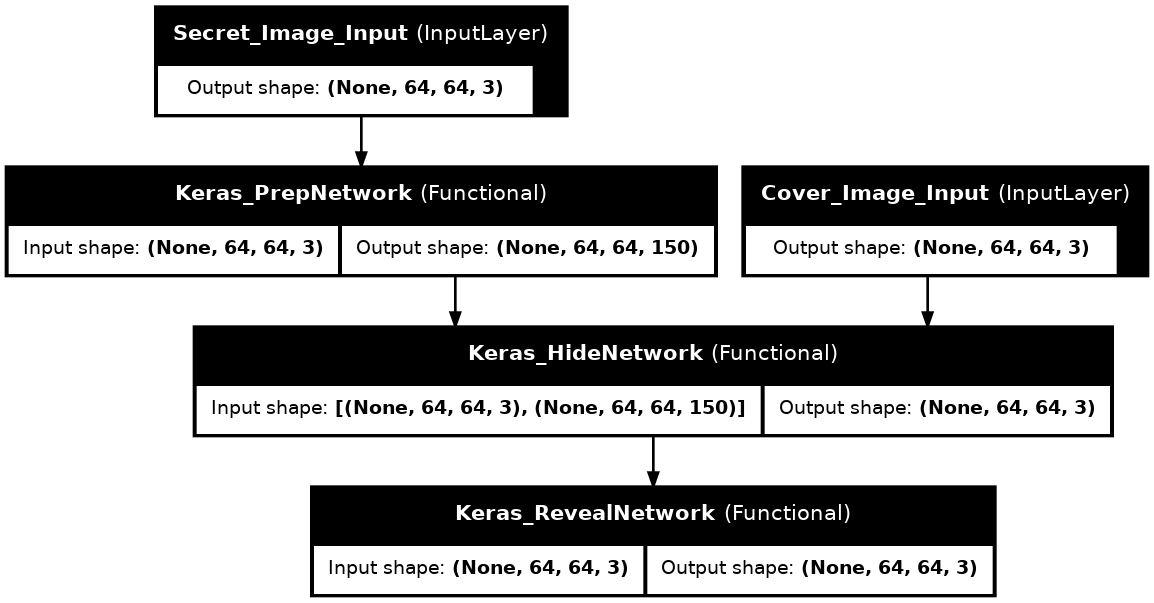

In [7]:
import shutil
import os


# Check if the folder exists, then delete it
if CLEAR_BEFORE_TRAIN and os.path.exists(checkpoint_dir) and os.path.exists(models_dir):
    try:
        shutil.rmtree(checkpoint_dir)
        shutil.rmtree(models_dir)
        print(
            f"🗑️  Existing checkpoints in '{checkpoint_dir}' and models in '{models_dir}' have been cleared.")
    except Exception as e:
        print(f"⚠️  Error clearing checkpoints: {e}")

os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

# Create the integrated model
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model = StegoSystem(prep_network, hide_network, reveal_network)
model.build([(None, 64, 64, 3), (None, 64, 64, 3)])
model.summary()

# add special plot to model how this will be used


def plot_steganography_graph():
    # 1. Define the overall inputs
    secret_in = tf.keras.Input(shape=(64, 64, 3), name="Secret_Image_Input")
    cover_in = tf.keras.Input(shape=(64, 64, 3), name="Cover_Image_Input")

    # 2. Connect the existing sub-networks
    # This mirrors exactly what happens in your train_step
    prep_out = prep_network(secret_in)
    stego_out = hide_network([cover_in, prep_out])
    reveal_out = reveal_network(stego_out)

    # 3. Create a temporary "Visualization Model"
    viz_model = tf.keras.Model(
        inputs=[cover_in, secret_in],
        outputs=[stego_out, reveal_out],
        name="Steganography_Architecture"
    )

    # 4. Plot with expansion
    return tf.keras.utils.plot_model(
        viz_model,
        to_file='steganography_full_flow.png',
        show_shapes=True,
        show_dtype=False,
        show_layer_names=True,
        rankdir='TB',
        expand_nested=False,
        dpi=96,
        layer_range=None,
        show_layer_activations=False
    )


# Execute the plot
plot_steganography_graph()

In [8]:
model.compile(optimizer=optimizer)

# Callback to save every 10 epochs
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='checkpoints/stego_best_val.weights.h5',
    monitor='val_loss',  # Monitors the validation loss from test_step
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
)


class SaveEveryTen(tf.keras.callbacks.Callback):
    def __init__(self, checkpoint_dir, max_to_keep=3):
        super().__init__()
        self.checkpoint_dir = checkpoint_dir
        self.max_to_keep = max_to_keep
        # Track saved epochs to know what to delete
        self.saved_epochs = []

    def on_epoch_end(self, epoch, logs=None):
        current_epoch = epoch + 1

        if current_epoch % 10 == 0:
            print(f"\n✅ Milestone: Epoch {current_epoch} completed.")

            # 1. Manage rotation: if we already have 3, delete the oldest
            if len(self.saved_epochs) >= self.max_to_keep:
                oldest_epoch = self.saved_epochs.pop(0)
                self._delete_checkpoint(oldest_epoch)

            # 2. Save the new models
            self._save_checkpoint(current_epoch)
            self.saved_epochs.append(current_epoch)

    def _save_checkpoint(self, epoch):
        nets = ['prep', 'hide', 'reveal']
        for net_name in nets:
            net = getattr(self.model, f"{net_name}_net")
            path = os.path.join(self.checkpoint_dir,
                                f'{net_name}_model_checkpoint_{epoch}.keras')
            net.save(path)

    def _delete_checkpoint(self, epoch):
        nets = ['prep', 'hide', 'reveal']
        for net_name in nets:
            path = os.path.join(self.checkpoint_dir,
                                f'{net_name}_model_checkpoint_{epoch}.keras')
            if os.path.exists(path):
                os.remove(path)


save_callback = SaveEveryTen(checkpoint_dir=checkpoint_dir, max_to_keep=3)

# Train using Keras Fit
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    steps_per_epoch=STEPS,
    validation_data=test_dataset,
    callbacks=[checkpoint_callback, save_callback],
    verbose=1
)


model.prep_net.save(prep_model_path)
model.hide_net.save(hide_model_path)
model.reveal_net.save(reveal_model_path)
print("Training completed.Final model states saved.")

results = model.evaluate(test_dataset)
print(
    f"Validation Results - Total Loss: {results[0]:.4f}, Cover Loss: {results[1]:.4f}, Secret Loss: {results[2]:.4f}")

Epoch 1/100


I0000 00:00:1774313586.309787   44121 service.cc:153] XLA service 0x7a20d4061500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774313586.309816   44121 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774313586.397192   44121 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774313587.838784   44121 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774313603.775731   44121 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - cover_loss: 0.0675 - loss: 0.4550 - secret_loss: 0.0646
Epoch 1: val_loss improved from None to 0.30187, saving model to checkpoints/stego_best_val.weights.h5

Epoch 1: finished saving model to checkpoints/stego_best_val.weights.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 70s 198ms/step - cover_loss: 0.0636 - loss: 0.3827 - secret_loss: 0.0532 - val_cover_loss: 0.0751 - val_loss: 0.3019 - val_secret_loss: 0.0378
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - cover_loss: 0.0487 - loss: 0.2044 - secret_loss: 0.0260
Epoch 2: val_loss improved from 0.30187 to 0.15698, saving model to checkpoints/stego_best_val.weights.h5

Epoch 2: finished saving model to checkpoints/stego_best_val.weights.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 31s 131ms/step - cover_loss: 0.0389 - loss: 0.1808 - secret_loss: 0.0237 - val_cover_loss: 0.0306 - val_loss: 0.1570 - val_secret_loss: 0.0211
Epoch 3/100
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - cover_loss: 0.0275 - loss: 0.1

### Final Testing / Example Output


In [39]:
# Prep lsb / huffman code
from LSB_Steganography.LSBSteg import LSBSteg
from dahuffman import HuffmanCodec
import matplotlib.pyplot as plt
import pandas as pd
import struct
from reedsolo import RSCodec
from scipy import stats
# from https://github.com/RobinDavid/LSB-Steganography/tree/master

rs = RSCodec(32)


def lsb_extract_robust(image, codec):
    steg = LSBSteg(image)

    # 1. Calculate the absolute physical limit of the image
    # (Width * Height * Channels) // 8 bits per byte
    max_bytes = (image.shape[0] * image.shape[1] * image.shape[2]) // 8

    try:
        # 2. Extract the raw bitstream from the image
        raw_binary = steg.decode_binary()
        if len(raw_binary) < 12:
            return ""  # Need at least 3 length headers (4 bytes each)

        # 3. MAJORITY VOTE ON HEADER
        # We read the first 12 bytes as three separate 32-bit integers
        h1 = struct.unpack('I', raw_binary[0:4])[0]
        h2 = struct.unpack('I', raw_binary[4:8])[0]
        h3 = struct.unpack('I', raw_binary[8:12])[0]

        # Use a simple list to find the most common value (mode)
        headers = [h1, h2, h3]
        data_len = max(set(headers), key=headers.count)

        # 4. SANITY CHECK: Hard-cap the length to the image capacity
        # If the voted length is still crazy or 0, the noise is too high
        if data_len > (max_bytes - 12) or data_len <= 0:
            raise ValueError("Header Unrecoverable")

        # 5. Extract the ECC block using the safe length
        ecc_content = raw_binary[12: 12 + data_len]
        # Debug: Show the first 20 bytes of ECC content
        # 6. Repair and Decode
        repaired_huff_bytes = rs.decode(ecc_content)[0]
        return codec.decode(repaired_huff_bytes)

    except Exception as e:
        print(f"[Unrecoverable: {str(e)[:30]}]")
        return ""


def lsb_embed_robust(text, image_array, codec):
    huff_bytes = codec.encode(text)
    ecc_bytes = rs.encode(huff_bytes)

    # Triple the length header for redundancy
    length_bin = struct.pack('I', len(ecc_bytes))
    header = length_bin * 3  # 12 bytes total

    data_to_hide = header + ecc_bytes

    steg = LSBSteg(image_array)
    return steg.encode_binary(data_to_hide)


def calculate_ber(original, revealed):

    # Ensure we are working with 8-bit integer representations
    # We use np.clip to ensure values stay within 0-255 before casting
    orig_uint8 = np.clip(original * 255, 0, 255).astype(np.uint8)
    rev_uint8 = np.clip(revealed * 255, 0, 255).astype(np.uint8)

    # Unpack the 8-bit integers into a bit array
    # axis=-1 expands the bits for each color channel
    orig_bits = np.unpackbits(orig_uint8)
    rev_bits = np.unpackbits(rev_uint8)

    # Calculate the ratio of flipped bits to total bits
    mismatched_bits = np.sum(orig_bits != rev_bits)
    total_bits = orig_bits.size

    return mismatched_bits / total_bits


def load_weights_from_checkpoint(models_dir, prep_net, hide_net, reveal_net):

    # Verify all files exist before attempting to load
    if not all(os.path.exists(p) for p in [prep_model_path, hide_model_path, reveal_model_path]):
        raise FileNotFoundError(
            f"⛔ CRITICAL: One or more .keras files not found in {models_dir}. "
            "Ensure you have run the individual .save() commands first."
        )

    prep_net = tf.keras.models.load_model(prep_model_path)
    hide_net = tf.keras.models.load_model(hide_model_path)
    reveal_net = tf.keras.models.load_model(reveal_model_path)
    print(f"💎 Individual weights successfully loaded from {models_dir}")
    return prep_net, hide_net, reveal_net


def to_display(img_tensor):
    # 1. Convert to numpy and remove batch dim
    arr = img_tensor.numpy().squeeze()

    # 2. Scale to 0-255
    scaled = arr * 255

    # 3. ROUND to the nearest integer, then clip, then cast
    return np.clip(np.round(scaled), 0, 255).astype(np.uint8)


def plot_final_summary(history, all_metrics, sample_images, epoch_interval=10):
    """
    Creates a full visual report: 
    Training History + Metrics Table + Evaluation Graphs + Image Samples
    """
    # Convert history to a Pandas DataFrame for easier plotting/handling
    df_history = pd.DataFrame(history.history)
    df_history.index = df_history.index + 1  # Offset index to match 1-based Epochs

    # --- STEP 1: CREATE METRICS TABLE ---
    # We filter the history to show every Nth epoch (e.g., every 10)
    summary_table = df_history.iloc[epoch_interval-1::epoch_interval].copy()

    # If your history doesn't contain PSNR/SSIM, you'd add them here from all_metrics
    # For now, let's display what's available in the history object
    print("-" * 30)
    print(f"Summary Metrics (Every {epoch_interval} Epochs)")
    print("-" * 30)
    display(summary_table)

    # --- ROW 1: STATISTICAL GRAPHS ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig1, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

    # 1. Total Loss (Using Pandas .plot)
    df_history[['loss', 'val_loss']].plot(
        ax=ax1, color=['#2ecc71', '#e74c3c'], lw=2)
    ax1.set_title('Model Convergence', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('MSE')
    ax1.legend(['Train Loss', 'Val Loss'])

    # 2. Individual Component Losses
    if 'cover_loss' in df_history.columns:
        df_history[['cover_loss', 'secret_loss']].plot(
            ax=ax2, color=['#3498db', '#9b59b6'])
        ax2.set_title('Loss Breakdown', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Epochs')
        ax2.legend(['Cover (Invisibility)', 'Secret (Recovery)'])

    # 3. Final PSNR Comparison (Aggregated from all_metrics)
    avg_metrics = {
        'Cover PSNR': np.mean(all_metrics['psnr_c']),
        'Secret PSNR': np.mean(all_metrics['psnr_s'])
    }
    # Convert to Series for quick plotting
    pd.Series(avg_metrics).plot(
        kind='bar', ax=ax3, color=['#34495e', '#16a085'])
    ax3.set_title('Avg. PSNR', fontsize=14, fontweight='bold')
    ax3.set_ylabel('dB')
    ax3.set_ylim(0, max(avg_metrics.values()) + 15)

    # Adding labels on top of bars
    for i, v in enumerate(avg_metrics.values()):
        ax3.text(i, v + 1, f'{v:.2f} dB', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # --- ROW 2: VISUAL EXAMPLE ---
    titles = ["Original Secret", "Original Cover",
              "Cover (Hidden)", "Revealed Secret"]
    fig2, axes = plt.subplots(1, 4, figsize=(20, 6))
    fig2.suptitle('Visual Steganography Results',
                  fontsize=16, fontweight='bold', y=1.05)

    for i, ax in enumerate(axes):
        ax.imshow(sample_images[i])
        ax.set_title(titles[i], fontsize=12)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

💎 Individual weights successfully loaded from ./models
Evaluating 1000 samples...
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]
[Unrecoverable: No available slot remaining (i]

=== Final Evaluation Metrics ===
Secret text accuracy: 0.00%
Revealed text: ""
------------------------------
Summary Metrics (Every 10 Epochs)
------------------------------


,cover_loss,loss,secret_loss,val_cover_loss,val_loss,val_secret_loss
10,0.017291,0.062144,0.007476,0.019969,0.092570,0.012100
20,0.015329,0.050809,0.005913,0.018341,0.054355,0.006002
30,0.015623,0.047898,0.005379,0.017671,0.048319,0.005108
40,0.018135,0.048740,0.005101,0.020284,0.049320,0.004839
50,0.021899,0.050401,0.004750,0.023747,0.049744,0.004333
60,0.026047,0.049972,0.003987,0.028015,0.052585,0.004095
70,0.031287,0.052965,0.003613,0.033095,0.056835,0.003957
80,0.033735,0.054976,0.003540,0.035106,0.058602,0.003916
90,0.034970,0.055848,0.003480,0.036352,0.059431,0.003846
100,0.035460,0.056221,0.003460,0.036621,0.059570,0.003825


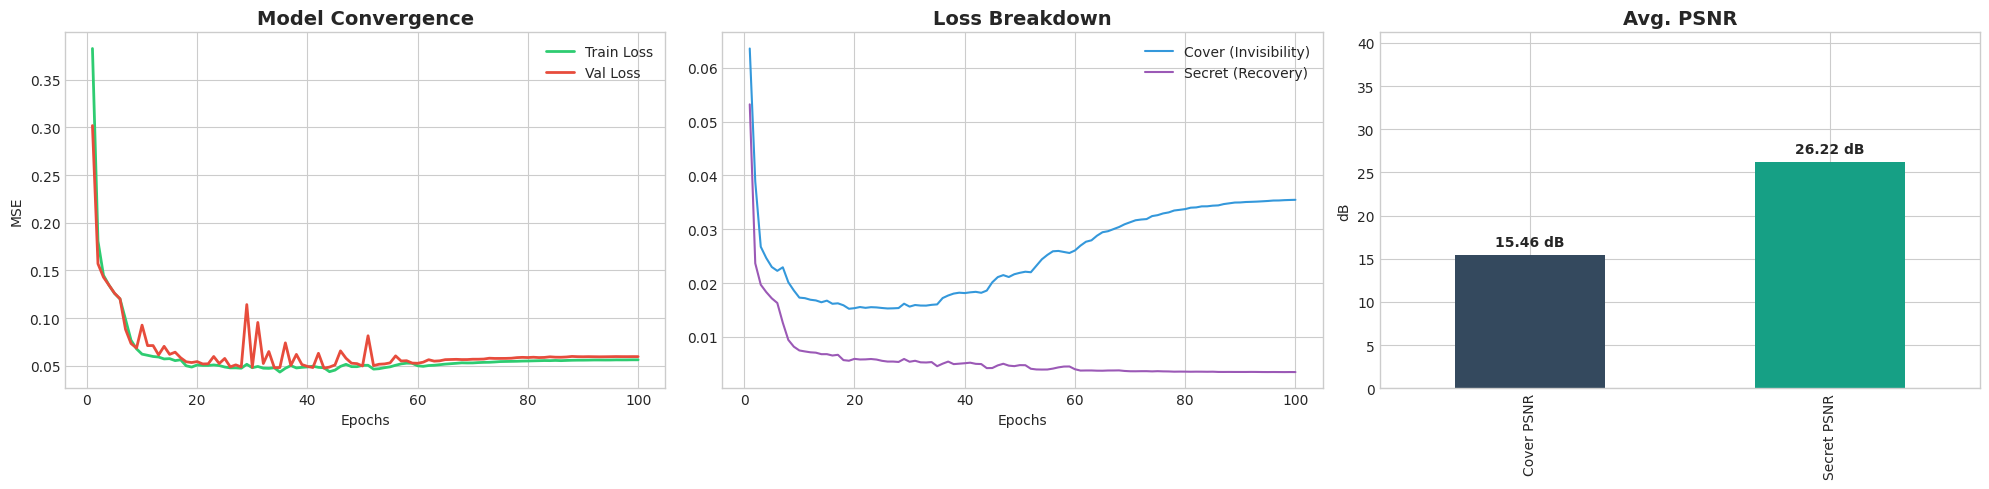

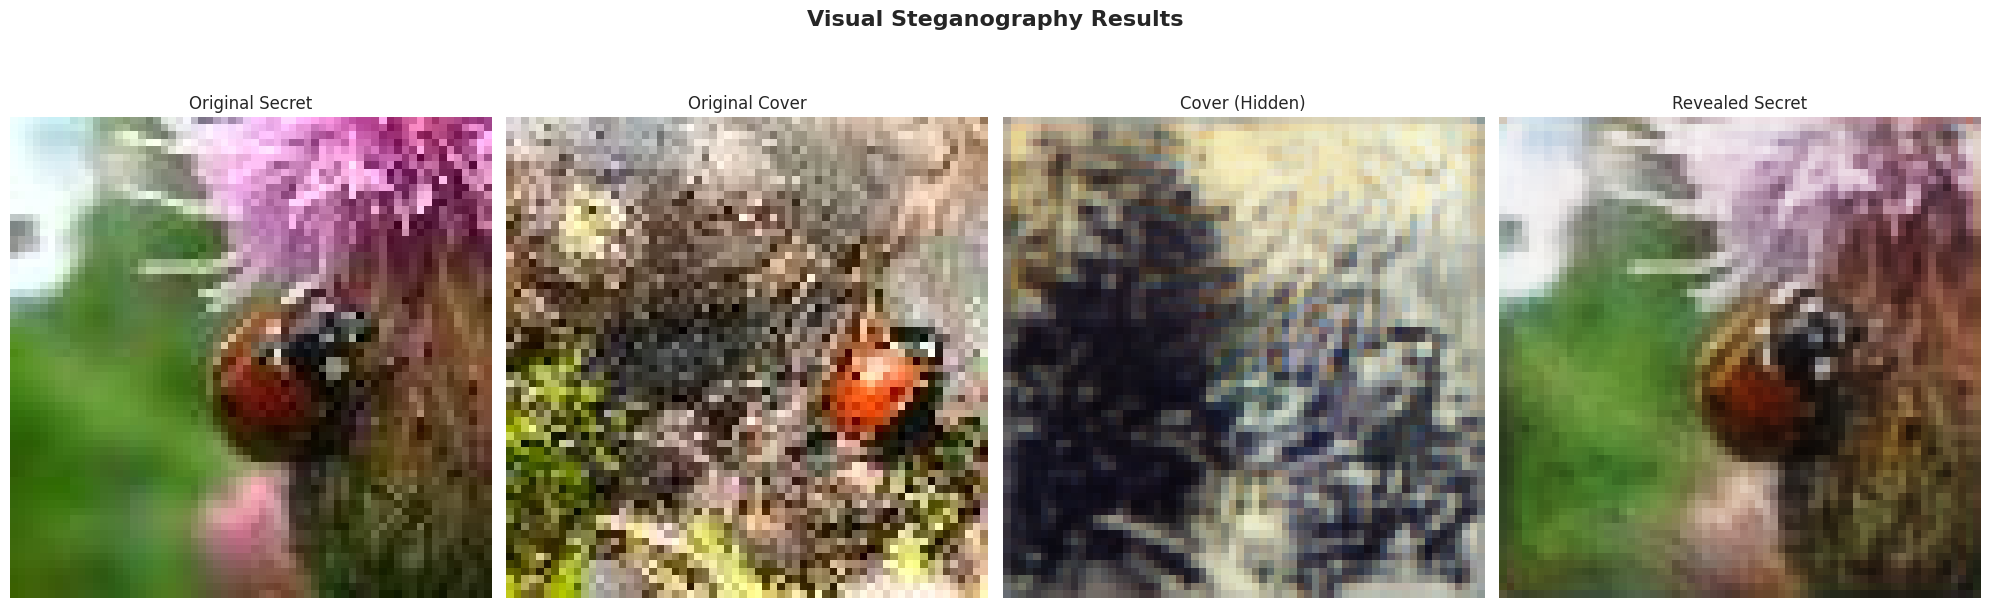

In [40]:

# reload just to check saved model works, and so this can be run without fit if needed.
prep_network, hide_network, reveal_network = load_weights_from_checkpoint(
    models_dir, prep_network, hide_network, reveal_network
)

# --- 1. Setup Accumulators ---
all_metrics = {
    "total_loss": [], "cover_loss": [], "secret_loss": [],
    "psnr_c": [], "ssim_c": [], "psnr_s": [], "ssim_s": [],
    "ber": [], 'text_acc': []
}

# Assuming test_cover_np and test_secret_np are your full holdout arrays
num_samples = len(holdout_cover_np)
secret_text = "Hello World!\0"
codec = HuffmanCodec.from_data(secret_text)
modified_holdout_secret_np = []

for j in range(num_samples):
    new_secret = lsb_embed_robust(secret_text, holdout_secret_np[j], codec)
    modified_holdout_secret_np.append(new_secret)

print(f"Evaluating {num_samples} samples...")

for i in range(10):
    # Prepare single sample
    sc = to_scale(holdout_cover_np[i:i+1])
    ss = to_scale(np.array(modified_holdout_secret_np[i:i+1]))

    # Inference
    p_out = tf.cast(prep_network(ss), tf.float32)
    h_out = tf.cast(hide_network([sc, p_out]), tf.float32)
    r_out = tf.cast(reveal_network(h_out), tf.float32)
    rev_img = to_display(r_out)

    # --- THE FIX: Robust Text Recovery ---
    try:
        # If the NN noise flips an LSB, this throws an error. We catch it so the notebook survives.
        revealed_text = lsb_extract_robust(rev_img, codec)
    except Exception as e:
        revealed_text = ""
        print(
            f"Sample {i+1}: LSB decoding failed due to network noise. with error: {e}")

    # Calculate Text Accuracy (Fixing the shadowed 'i' variable)
    if len(revealed_text) == 0 or revealed_text.startswith("[Unrecoverable"):
        text_acc = 0.0
    else:
        # Compare char[i] == char[i] safely using zip
        match_count = sum(1 for s_char, r_char in zip(
            secret_text, revealed_text) if s_char == r_char)

        # Divide by the original length to get the true accuracy
        text_acc = match_count / len(secret_text)

    all_metrics['text_acc'].append(text_acc)
    # Calculate Losses
    t_loss, c_loss, s_loss = steganography_loss(sc, ss, h_out, r_out)

    # Calculate Quality Metrics
    p_c = tf.image.psnr(sc, h_out, max_val=1.0)
    s_c = tf.image.ssim(sc, h_out, max_val=1.0)
    p_s = tf.image.psnr(ss, r_out, max_val=1.0)
    s_s = tf.image.ssim(ss, r_out, max_val=1.0)
    ber = calculate_ber(ss, r_out)

    # Append to lists (using .numpy() to get scalars)
    all_metrics["total_loss"].append(t_loss.numpy())
    all_metrics["cover_loss"].append(c_loss.numpy())
    all_metrics["secret_loss"].append(s_loss.numpy())
    all_metrics["psnr_c"].append(p_c.numpy()[0])
    all_metrics["ssim_c"].append(s_c.numpy()[0])
    all_metrics["psnr_s"].append(p_s.numpy()[0])
    all_metrics["ssim_s"].append(s_s.numpy()[0])
    all_metrics["ber"].append(ber)

# --- 2. Final Averaging ---
last_samples = [to_display(ss), to_display(
    sc), to_display(h_out), to_display(r_out)]
print("\n=== Final Evaluation Metrics ===")
print(f"Secret text accuracy: {np.mean(all_metrics['text_acc'])*100:.2f}%")
print(f"Revealed text: \"{revealed_text}\"")
plot_final_summary(history, all_metrics, last_samples)